In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Path to dataset files: /kaggle/input/gtzan-dataset-music-genre-classification


In [3]:
import shutil
import os

# Define the initial base path to the original images from the downloaded dataset
# The 'path' variable comes from the previous cell execution.
base_images_path = os.path.join(path, 'Data', 'images_original')

# Define valid image extensions, as this is used later in the cell
valid_extensions = ('.png', '.jpg', '.jpeg')

# Define a new writable path for the dataset in /kaggle/working
writable_data_root = os.path.join('/kaggle/working', 'gtzan_processed_data')
writable_images_path = os.path.join(writable_data_root, 'Data', 'images_original')

# Check if the writable directory already exists from a previous run and clear it if needed
if os.path.exists(writable_data_root):
    shutil.rmtree(writable_data_root)
    print(f"Removed existing writable data root: {writable_data_root}")

# Copy the entire original dataset structure to the writable location
# Copy from the parent directory of base_images_path to preserve 'Data' folder structure
print(f"Copying original data from {os.path.dirname(os.path.dirname(base_images_path))} to {writable_data_root}...")
shutil.copytree(os.path.dirname(os.path.dirname(base_images_path)), writable_data_root)
print("Original dataset copied to writable location.")

# Update base_images_path to point to the new writable location
# This is crucial so that all subsequent operations use the writable copy.
base_images_path = writable_images_path
print(f"Updated base_images_path to: {base_images_path}")

# Re-list genres based on the new `base_images_path` to ensure consistency
genres = sorted([d for d in os.listdir(base_images_path) if os.path.isdir(os.path.join(base_images_path, d))])
print(f"Re-evaluated genres based on new base_images_path: {genres}")

# 1. Construct the path to the 'jazz' genre folder within the *writable* dataset
jazz_path = os.path.join(base_images_path, 'jazz')

# 2. List all image files within the 'jazz' folder
jazz_images = [f for f in os.listdir(jazz_path) if f.lower().endswith(valid_extensions)]

if jazz_images:
    # 3. Select the first image file from the list to be duplicated
    image_to_duplicate = jazz_images[0]
    src_file_path = os.path.join(jazz_path, image_to_duplicate)

    # 4. Define the destination path for the duplicate image
    file_name_without_ext, file_extension = os.path.splitext(image_to_duplicate)
    dest_file_name = f"{file_name_without_ext}_duplicate{file_extension}"
    dest_file_path = os.path.join(jazz_path, dest_file_name) # This will now be in the writable location

    # 5. Use shutil.copy2() to copy the selected image file to the new destination
    shutil.copy2(src_file_path, dest_file_path)

    # 6. Print a confirmation message
    print(f"Duplicated '{image_to_duplicate}' to '{dest_file_name}' in the 'jazz' folder (writable copy).")
else:
    print("No image files found in the 'jazz' folder to duplicate.")

Copying original data from /kaggle/input/gtzan-dataset-music-genre-classification to /kaggle/working/gtzan_processed_data...
Original dataset copied to writable location.
Updated base_images_path to: /kaggle/working/gtzan_processed_data/Data/images_original
Re-evaluated genres based on new base_images_path: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Duplicated 'jazz00077.png' to 'jazz00077_duplicate.png' in the 'jazz' folder (writable copy).


In [4]:
import os

# 1. Update the genres list with the current base_images_path
genres = sorted([d for d in os.listdir(base_images_path) if os.path.isdir(os.path.join(base_images_path, d))])

# 2. Verify integrity and count images per genre in the updated path
summary = {}
valid_extensions = ('.png', '.jpg', '.jpeg')

for genre in genres:
    genre_path = os.path.join(base_images_path, genre)
    files = os.listdir(genre_path)
    # Filter only image files
    image_files = [f for f in files if f.lower().endswith(valid_extensions)]
    non_image_files = [f for f in files if not f.lower().endswith(valid_extensions)]

    summary[genre] = len(image_files)

    if genre == 'jazz':
        print(f"\nVerification: Jazz folder now contains {len(image_files)} images (Expected: 100).")

    if non_image_files:
        print(f"Warning: Non-image files found in {genre}: {non_image_files}")

print("\nSummary of images per genre (after duplication in jazz):")
for genre, count in summary.items():
    print(f"- {genre}: {count} images")



Verification: Jazz folder now contains 100 images (Expected: 100).

Summary of images per genre (after duplication in jazz):
- blues: 100 images
- classical: 100 images
- country: 100 images
- disco: 100 images
- hiphop: 100 images
- jazz: 100 images
- metal: 100 images
- pop: 100 images
- reggae: 100 images
- rock: 100 images


In [17]:
import shutil
import os

# Define base directory for the split dataset
# Changed to an absolute path within /kaggle/working for consistency
split_base_dir = os.path.join('/kaggle/working', 'gtzan_split')

# 1. Remove the existing 'gtzan_split' directory if it exists
if os.path.exists(split_base_dir):
    shutil.rmtree(split_base_dir)
    print(f"Removed existing split directory: {split_base_dir}")

print(f"Ready to re-create directory structure for: {split_base_dir}")

Ready to re-create directory structure for: /kaggle/working/gtzan_split


In [18]:
import os

# 1. Define base directory for the split dataset
# Using the updated split_base_dir from previous cells
splits = ['train', 'val', 'test']

# 2, 3 & 4. Create directories for each split and genre
for split in splits:
    for genre in genres:
        directory_path = os.path.join(split_base_dir, split, genre)
        os.makedirs(directory_path, exist_ok=True)

print(f"Created directory structure under: {split_base_dir}")
# 5. Verify structure
for split in splits:
    subdirs = os.listdir(os.path.join(split_base_dir, split))
    print(f"- {split} contains {len(subdirs)} genre folders.")

Created directory structure under: /kaggle/working/gtzan_split
- train contains 10 genre folders.
- val contains 10 genre folders.
- test contains 10 genre folders.


In [20]:
import random
import shutil

# 1. Set random seed for reproducibility
random.seed(42)

# 2. Define splits
split_ratios = {'train': 0.8, 'val': 0.1, 'test': 0.1}

for genre in genres:
    # 3. List image files for the genre
    genre_src_dir = os.path.join(base_images_path, genre)
    files = [f for f in os.listdir(genre_src_dir) if f.lower().endswith(valid_extensions)]

    # 4. Shuffle the files
    random.shuffle(files)

    # 5. Calculate split indices
    num_files = len(files)
    train_end = int(num_files * split_ratios['train'])
    val_end = train_end + int(num_files * split_ratios['val'])

    # 6. Define split dictionary mapping
    file_splits = {
        'train': files[:train_end],
        'val': files[train_end:val_end],
        'test': files[val_end:]
    }

    # 7. Copy files to destination
    for split_name, split_files in file_splits.items():
        dest_dir = os.path.join(split_base_dir, split_name, genre)
        for file_name in split_files:
            src_file = os.path.join(genre_src_dir, file_name)
            shutil.copy2(src_file, dest_dir)

print(f"Successfully re-split and copied images for all {len(genres)} genres into '{split_base_dir}'.")

Successfully re-split and copied images for all 10 genres into '/kaggle/working/gtzan_split'.


In [21]:
import os

# 1. Define splits
splits = ['train', 'val', 'test']

# 2. Initialize storage for counts
split_counts = {split: {} for split in splits}
valid_extensions = ('.png', '.jpg', '.jpeg')

# 3 & 4. Loop through directories and count files
for split in splits:
    for genre in genres:
        genre_path = os.path.join(split_base_dir, split, genre)
        if os.path.exists(genre_path):
            files = [f for f in os.listdir(genre_path) if f.lower().endswith(valid_extensions)]
            split_counts[split][genre] = len(files)
        else:
            split_counts[split][genre] = 0

# 5. Print formatted summary
print(f"{'Genre':<15} | {'Train':<8} | {'Val':<8} | {'Test':<8} | {'Total':<8}")
print('-' * 55)

for genre in genres:
    tr = split_counts['train'].get(genre, 0)
    vl = split_counts['val'].get(genre, 0)
    ts = split_counts['test'].get(genre, 0)
    total = tr + vl + ts
    print(f"{genre:<15} | {tr:<8} | {vl:<8} | {ts:<8} | {total:<8}")

# 6. Explicit check for Jazz
jazz_total = split_counts['train']['jazz'] + split_counts['val']['jazz'] + split_counts['test']['jazz']
print(f"\nVerification: Jazz genre total images: {jazz_total} (Train: {split_counts['train']['jazz']}, Val: {split_counts['val']['jazz']}, Test: {split_counts['test']['jazz']})")

Genre           | Train    | Val      | Test     | Total   
-------------------------------------------------------
blues           | 80       | 10       | 10       | 100     
classical       | 80       | 10       | 10       | 100     
country         | 80       | 10       | 10       | 100     
disco           | 80       | 10       | 10       | 100     
hiphop          | 80       | 10       | 10       | 100     
jazz            | 80       | 10       | 10       | 100     
metal           | 80       | 10       | 10       | 100     
pop             | 80       | 10       | 10       | 100     
reggae          | 80       | 10       | 10       | 100     
rock            | 80       | 10       | 10       | 100     

Verification: Jazz genre total images: 100 (Train: 80, Val: 10, Test: 10)


In [27]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 2. Define standard target image size and batch size
IMG_SIZE = 224
BATCH_SIZE = 32

# Data augmentation layers are removed as per user request.
# Only resizing and rescaling will be applied.

# 4. Create preprocessing model (applied to all datasets)
img_preprocessing = Sequential([
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Rescaling(1./255)
], name="img_preprocessing")

print(f"Target Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print("Preprocessing layers (Resizing, Rescaling) defined successfully. Data augmentation is currently disabled.")

Target Image Size: 224x224
Batch Size: 32
Preprocessing layers (Resizing, Rescaling) defined successfully. Data augmentation is currently disabled.


In [28]:
import os
import tensorflow as tf

# Ensure split_base_dir is accessible and correctly defined
# (Assuming split_base_dir is globally defined from previous cells as '/kaggle/working/gtzan_split')

# 1. Load datasets from the split directories
train_path = os.path.join(split_base_dir, 'train')
val_path = os.path.join(split_base_dir, 'val')
test_path = os.path.join(split_base_dir, 'test')

print(f"Attempting to load train_ds from: {train_path}")
print(f"Does train_path exist? {os.path.exists(train_path)}")
print(f"Is train_path a directory? {os.path.isdir(train_path)}")
if os.path.exists(train_path) and os.path.isdir(train_path):
    print(f"Contents of train_path (first 5): {os.listdir(train_path)[:5]}...")
else:
    print("Train path does not exist or is not a directory.")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print(f"Attempting to load val_ds from: {val_path}")
print(f"Does val_path exist? {os.path.exists(val_path)}")
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print(f"Attempting to load test_ds from: {test_path}")
print(f"Does test_path exist? {os.path.exists(test_path)}")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 2. Apply preprocessing to all datasets (Resizing and Rescaling)
train_ds = train_ds.map(lambda x, y: (img_preprocessing(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (img_preprocessing(x, training=False), y), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (img_preprocessing(x, training=False), y), num_parallel_calls=tf.data.AUTOTUNE)

# Data augmentation (rotations, zooms, flips) is removed as per user request.
# train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

print("TensorFlow datasets created and transformation layers (preprocessing only) mapped.")

Attempting to load train_ds from: /kaggle/working/gtzan_split/train
Does train_path exist? True
Is train_path a directory? True
Contents of train_path (first 5): ['hiphop', 'reggae', 'pop', 'jazz', 'classical']...
Found 800 files belonging to 10 classes.
Attempting to load val_ds from: /kaggle/working/gtzan_split/val
Does val_path exist? True
Found 100 files belonging to 10 classes.
Attempting to load test_ds from: /kaggle/working/gtzan_split/test
Does test_path exist? True
Found 100 files belonging to 10 classes.
TensorFlow datasets created and transformation layers (preprocessing only) mapped.


In [23]:
import tensorflow as tf

# Configure datasets for performance
# Cache the datasets to memory to avoid repeated I/O operations
# Prefetch the next batch in the background while the model is training

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets optimized with caching, shuffling (for training), and prefetching.")

Datasets optimized with caching, shuffling (for training), and prefetching.


In [26]:
import tensorflow as tf
import os

# 1. Re-initialize a temporary dataset to access class_names
temp_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_base_dir, 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 2. Access the class_names attribute
class_names = temp_ds.class_names

# 3. Print the class_names list to verify
print("Identified Class Names:", class_names)
print(f"Total classes: {len(class_names)}")

Found 800 files belonging to 10 classes.
Identified Class Names: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total classes: 10


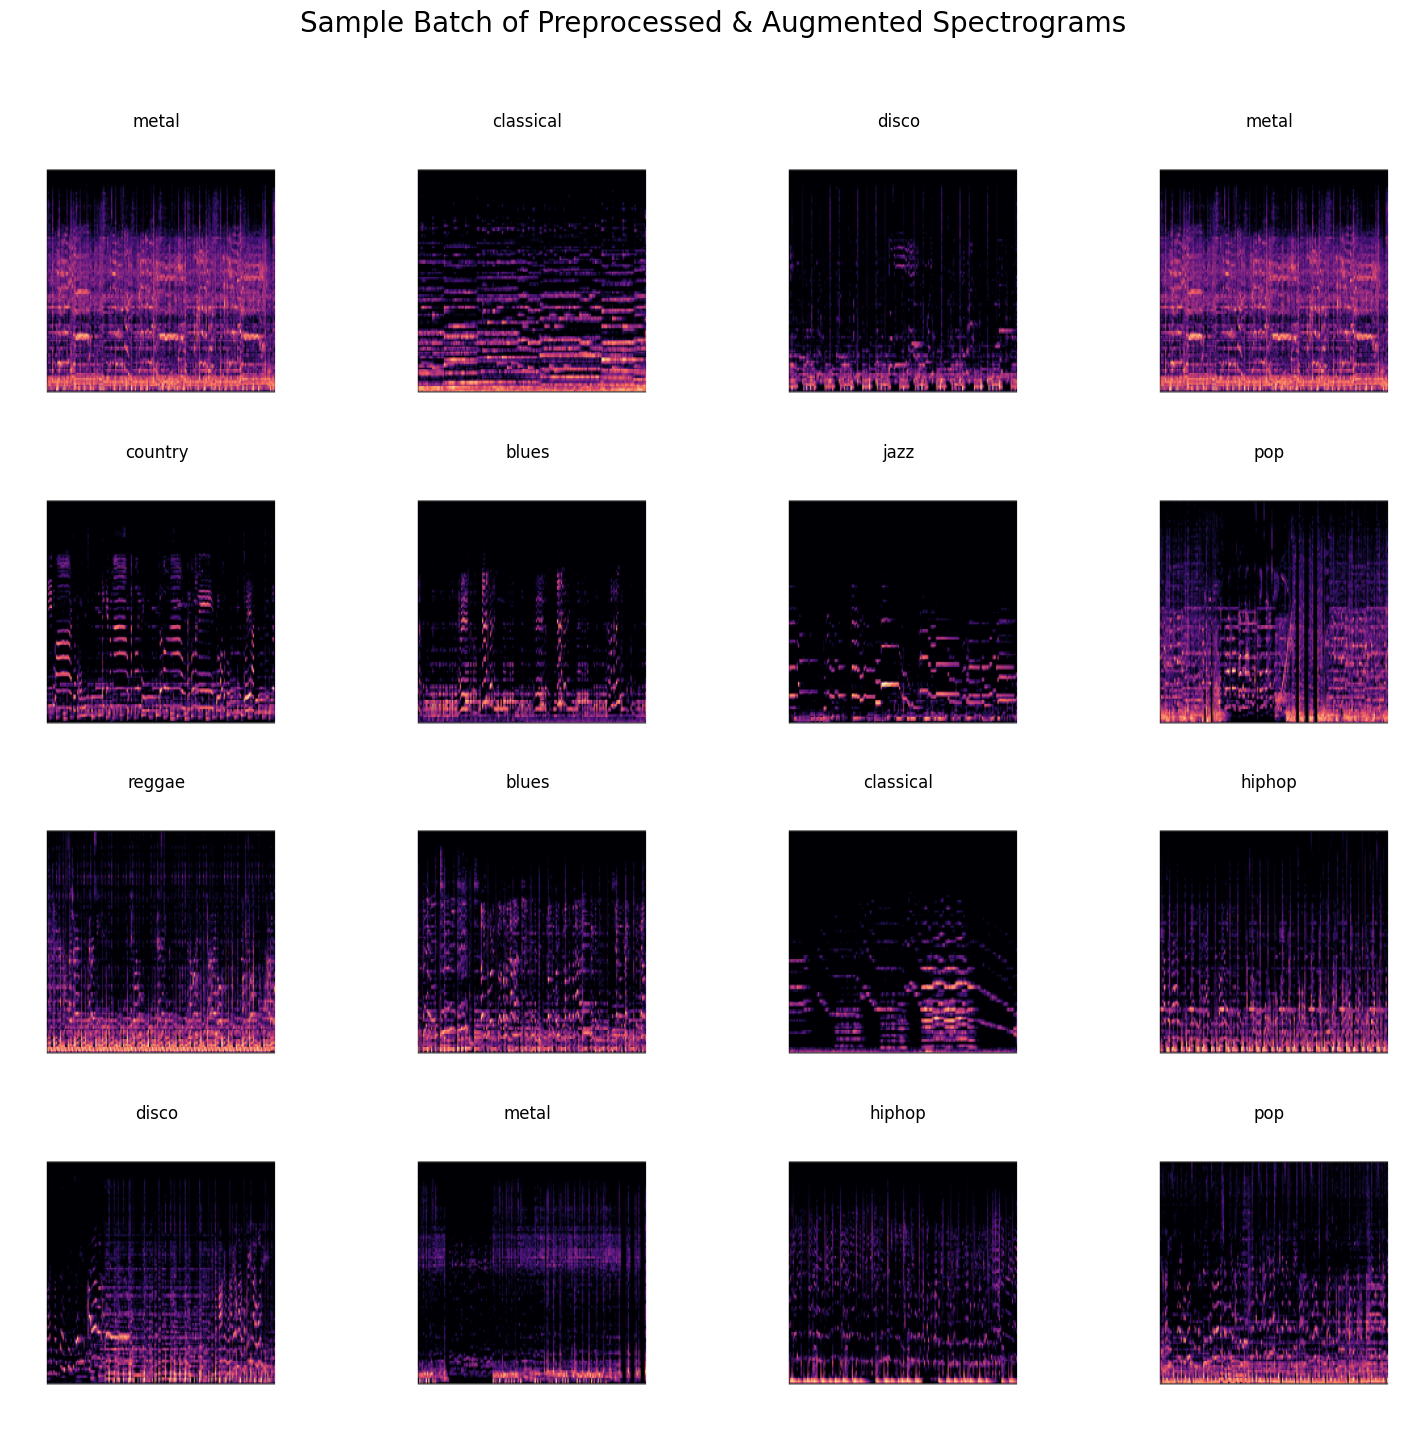

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Take a single batch from the training dataset
plt.figure(figsize=(15, 15))
for images, labels in train_ds.take(1):
    # 2. Iterate through the first 16 images in the batch
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)

        # 5. Display the image (already rescaled to [0, 1] and resized to 224x224)
        plt.imshow(images[i].numpy())

        # 3 & 4. Map one-hot label to class name
        label_index = np.argmax(labels[i])
        genre_name = class_names[label_index]

        # 6. Set title and clean up axis
        plt.title(genre_name)
        plt.axis("off")

plt.suptitle("Sample Batch of Preprocessed & Augmented Spectrograms", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()